In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import glob
import os

DATA_DIR = "../data/coco"
CLASSES = ["car", "bus", "truck"]
PALETTE = sns.color_palette("muted", 4)

In [2]:
results_files = glob.glob(f"{DATA_DIR}/*_results.csv")
perclass_files = glob.glob(f"{DATA_DIR}/*_perclass.csv")
preds_files = glob.glob(f"{DATA_DIR}/*_preds.csv")

if not results_files:
    raise FileNotFoundError("No results CSVs found. Run the evaluation notebooks first.")

summary_df = pd.concat([pd.read_csv(f) for f in results_files], ignore_index=True).sort_values("map50", ascending=False).reset_index(drop=True)
perclass_df = pd.concat([pd.read_csv(f) for f in perclass_files], ignore_index=True) if perclass_files else pd.DataFrame()

preds_map = {}
for f in preds_files:
    model_key = os.path.basename(f).replace("_preds.csv", "")
    preds_map[model_key] = pd.read_csv(f)

gt_df = pd.read_csv(f"{DATA_DIR}/annotations.csv")
models = summary_df["model"].tolist()
colors = {m: PALETTE[i] for i, m in enumerate(models)}

print(f"Models loaded: {models}")
print(f"Pred files loaded: {list(preds_map.keys())}")

Models loaded: ['RT-DETR-L', 'Faster R-CNN', 'YOLOv11n', 'YOLOv8n']
Pred files loaded: ['yolov11', 'faster_rcnn', 'yolov8', 'rtdetr']


## Radar chart — overall metrics

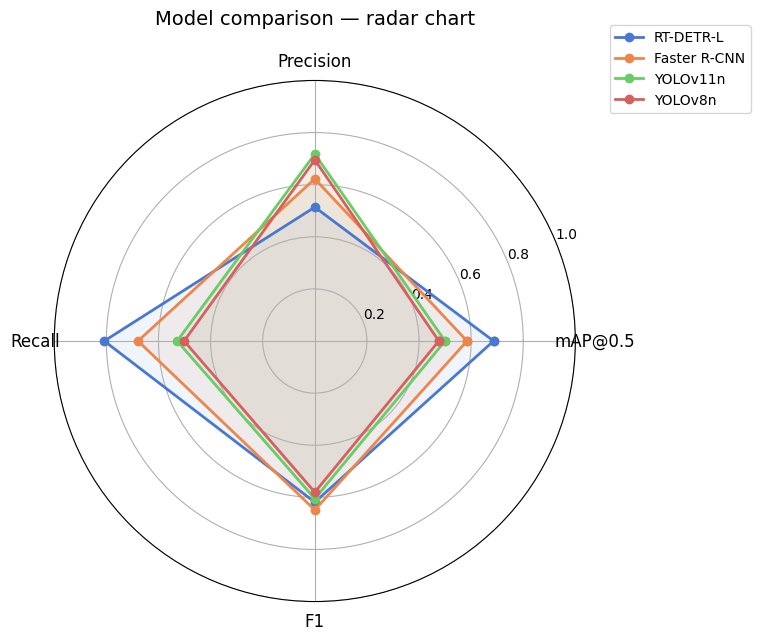

In [3]:
categories = ["mAP@0.5", "Precision", "Recall", "F1"]
metric_cols = ["map50", "precision", "recall", "f1"]
N = len(categories)
angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
angles += angles[:1]

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))

for i, row in summary_df.iterrows():
    vals = [row[c] for c in metric_cols] + [row[metric_cols[0]]]
    ax.plot(angles, vals, "o-", linewidth=2, color=PALETTE[i], label=row["model"])
    ax.fill(angles, vals, alpha=0.08, color=PALETTE[i])

ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories, fontsize=12)
ax.set_ylim(0, 1)
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.1f"))
ax.set_title("Model comparison — radar chart", fontsize=14, pad=20)
ax.legend(loc="upper right", bbox_to_anchor=(1.35, 1.12))
plt.tight_layout()
plt.savefig(f"{DATA_DIR}/analytics_radar.png", dpi=150, bbox_inches="tight")
plt.show()

## Per-class AP breakdown

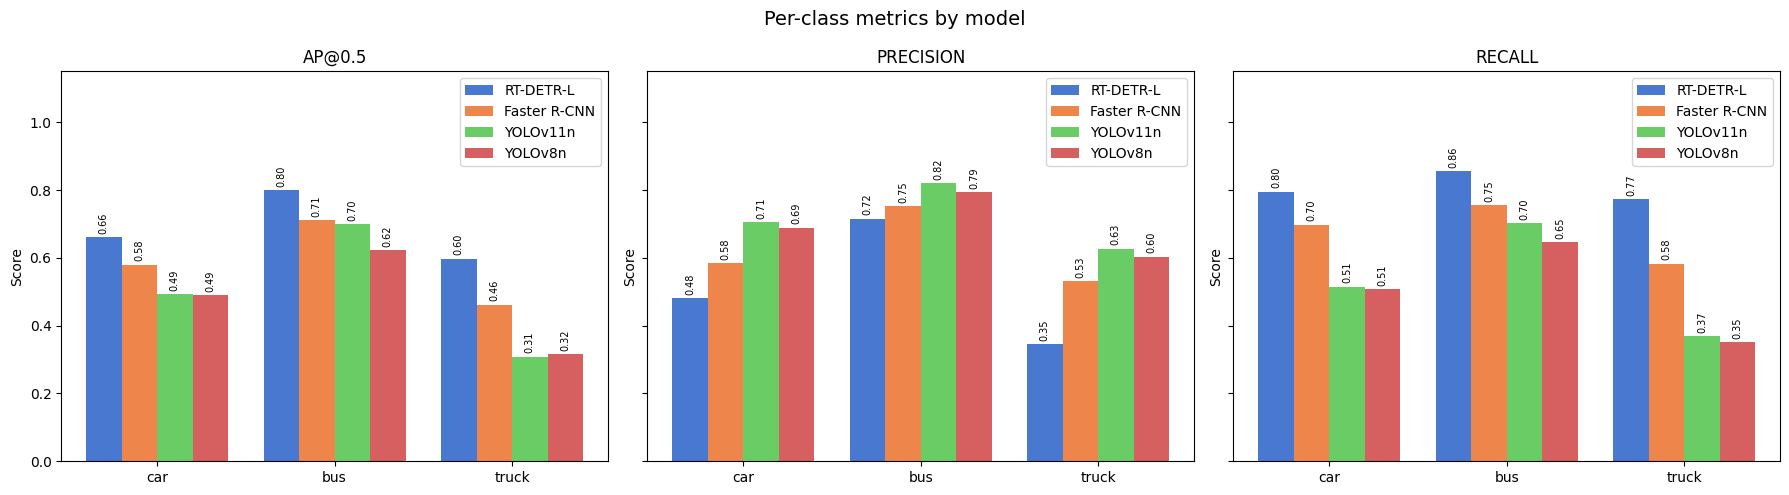

In [4]:
if not perclass_df.empty:
    fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

    for metric, ax in zip(["ap", "precision", "recall"], axes):
        x = np.arange(len(CLASSES))
        width = 0.8 / len(models)

        for i, model in enumerate(models):
            model_data = perclass_df[perclass_df["model"] == model]
            vals = [model_data.loc[model_data["class"] == cls, metric].values[0]
                    if cls in model_data["class"].values else 0
                    for cls in CLASSES]
            offset = (i - len(models) / 2 + 0.5) * width
            bars = ax.bar(x + offset, vals, width, label=model, color=PALETTE[i])
            for bar, v in zip(bars, vals):
                ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
                        f"{v:.2f}", ha="center", va="bottom", fontsize=7, rotation=90)

        ax.set_xticks(x)
        ax.set_xticklabels(CLASSES)
        ax.set_ylim(0, 1.15)
        ax.set_title(metric.upper().replace("AP", "AP@0.5"))
        ax.set_ylabel("Score")
        ax.legend()

    plt.suptitle("Per-class metrics by model", fontsize=14)
    plt.tight_layout()
    plt.savefig(f"{DATA_DIR}/analytics_perclass.png", dpi=150, bbox_inches="tight")
    plt.show()

## Confidence score distributions

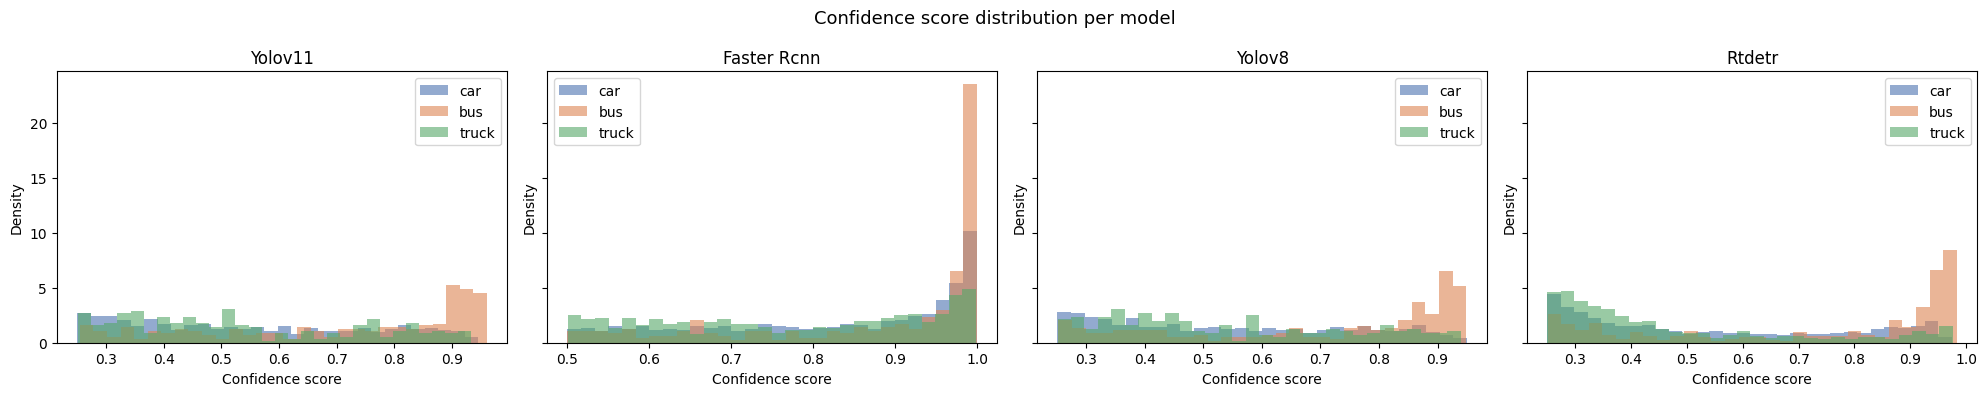

In [5]:
if preds_map:
    fig, axes = plt.subplots(1, len(preds_map), figsize=(5 * len(preds_map), 4), sharey=True)
    if len(preds_map) == 1:
        axes = [axes]

    for ax, (key, preds) in zip(axes, preds_map.items()):
        for cls, color in zip(CLASSES, ["#4C72B0", "#DD8452", "#55A868"]):
            cls_confs = preds.loc[preds["label"] == cls, "conf"]
            if not cls_confs.empty:
                ax.hist(cls_confs, bins=30, alpha=0.6, color=color, label=cls, density=True)
        ax.set_xlabel("Confidence score")
        ax.set_ylabel("Density")
        ax.set_title(key.replace("_", " ").title())
        ax.legend()

    plt.suptitle("Confidence score distribution per model", fontsize=13)
    plt.tight_layout()
    plt.savefig(f"{DATA_DIR}/analytics_confidence.png", dpi=150, bbox_inches="tight")
    plt.show()

## Precision-Recall curves per class

In [6]:
def compute_iou(box_a, box_b):
    xa = max(box_a[0], box_b[0])
    ya = max(box_a[1], box_b[1])
    xb = min(box_a[2], box_b[2])
    yb = min(box_a[3], box_b[3])
    inter = max(0, xb - xa) * max(0, yb - ya)
    area_a = (box_a[2] - box_a[0]) * (box_a[3] - box_a[1])
    area_b = (box_b[2] - box_b[0]) * (box_b[3] - box_b[1])
    return inter / (area_a + area_b - inter + 1e-6)

def precision_recall_curve(preds, gts, iou_thresh=0.5):
    if preds.empty or gts.empty:
        return np.array([0, 1]), np.array([0, 0])

    preds = preds.sort_values("conf", ascending=False).reset_index(drop=True)
    tp = np.zeros(len(preds))
    fp = np.zeros(len(preds))
    matched = set()

    for i, pred in preds.iterrows():
        img_gts = gts[gts["filepath"] == pred["filepath"]]
        best_iou, best_idx = 0, -1
        for j, gt in img_gts.iterrows():
            if j in matched:
                continue
            iou = compute_iou(
                [pred["x1"], pred["y1"], pred["x2"], pred["y2"]],
                [gt["x1"], gt["y1"], gt["x2"], gt["y2"]]
            )
            if iou > best_iou:
                best_iou, best_idx = iou, j
        if best_iou >= iou_thresh and best_idx != -1:
            tp[i] = 1
            matched.add(best_idx)
        else:
            fp[i] = 1

    cum_tp = np.cumsum(tp)
    cum_fp = np.cumsum(fp)
    recalls = cum_tp / (len(gts) + 1e-6)
    precisions = cum_tp / (cum_tp + cum_fp + 1e-6)
    return recalls, precisions

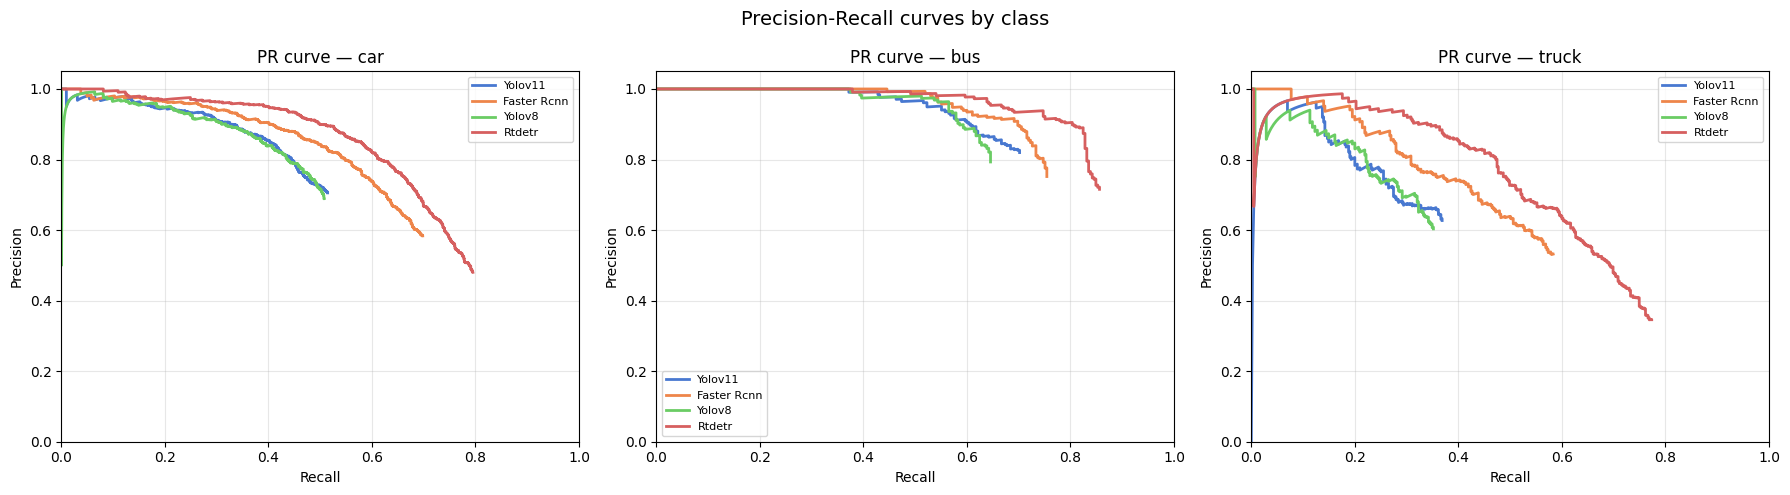

In [7]:
if preds_map:
    fig, axes = plt.subplots(1, len(CLASSES), figsize=(6 * len(CLASSES), 5))

    for ax, cls in zip(axes, CLASSES):
        cls_gts = gt_df[gt_df["label"] == cls]
        for i, (key, preds) in enumerate(preds_map.items()):
            cls_preds = preds[preds["label"] == cls]
            recalls, precisions = precision_recall_curve(cls_preds, cls_gts)
            ax.plot(recalls, precisions, linewidth=2, color=PALETTE[i],
                    label=key.replace("_", " ").title())

        ax.set_xlabel("Recall")
        ax.set_ylabel("Precision")
        ax.set_title(f"PR curve — {cls}")
        ax.set_xlim(0, 1)
        ax.set_ylim(0, 1.05)
        ax.legend(fontsize=8)
        ax.grid(True, alpha=0.3)

    plt.suptitle("Precision-Recall curves by class", fontsize=14)
    plt.tight_layout()
    plt.savefig(f"{DATA_DIR}/analytics_pr_curves.png", dpi=150, bbox_inches="tight")
    plt.show()

## Prediction count vs ground truth count

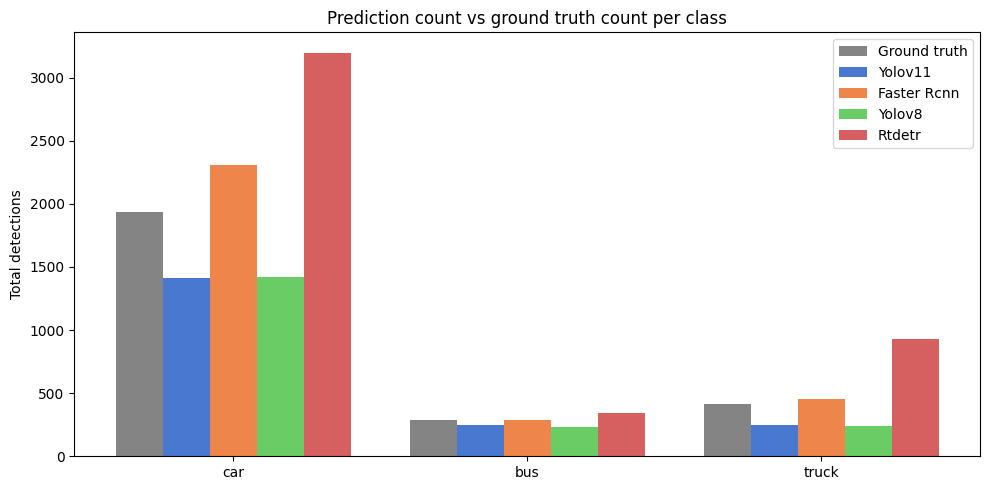

In [8]:
if preds_map:
    gt_counts = gt_df.groupby("label").size().reindex(CLASSES)

    fig, ax = plt.subplots(figsize=(10, 5))
    x = np.arange(len(CLASSES))
    width = 0.8 / (len(preds_map) + 1)

    ax.bar(x - width * len(preds_map) / 2, gt_counts, width, label="Ground truth",
           color="#333333", alpha=0.6)

    for i, (key, preds) in enumerate(preds_map.items()):
        pred_counts = preds.groupby("label").size().reindex(CLASSES, fill_value=0)
        offset = (i + 1 - len(preds_map) / 2) * width
        ax.bar(x + offset, pred_counts, width, label=key.replace("_", " ").title(),
               color=PALETTE[i])

    ax.set_xticks(x)
    ax.set_xticklabels(CLASSES)
    ax.set_ylabel("Total detections")
    ax.set_title("Prediction count vs ground truth count per class")
    ax.legend()
    plt.tight_layout()
    plt.savefig(f"{DATA_DIR}/analytics_pred_counts.png", dpi=150, bbox_inches="tight")
    plt.show()

## Per-class metric heatmaps

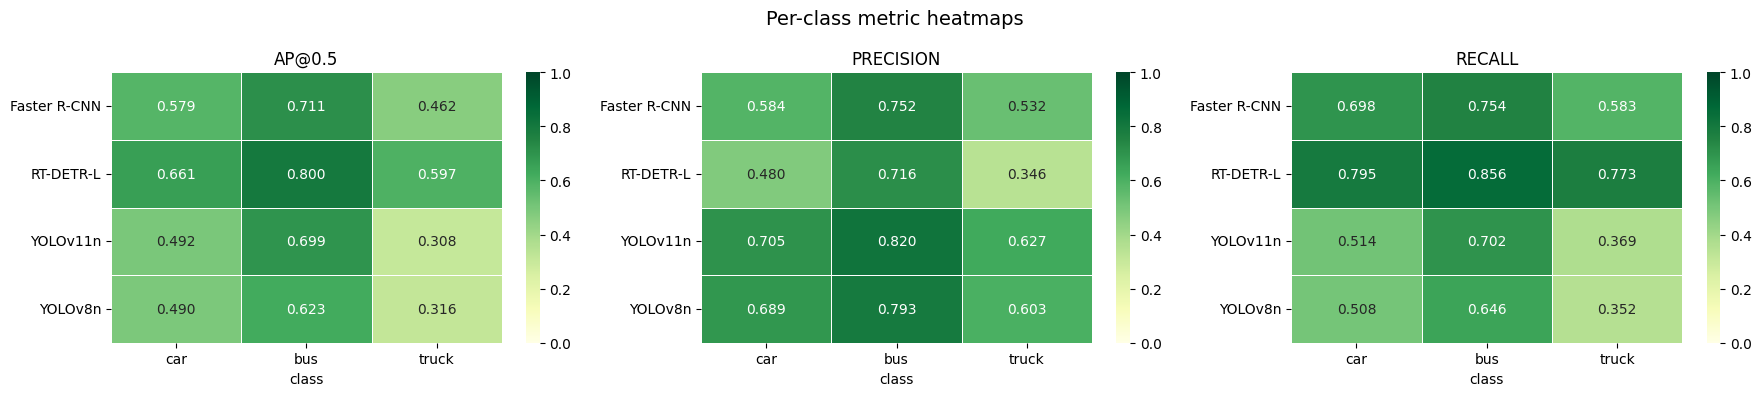

In [9]:
if not perclass_df.empty:
    fig, axes = plt.subplots(1, 3, figsize=(18, 4))

    for ax, metric in zip(axes, ["ap", "precision", "recall"]):
        pivot = perclass_df.pivot(index="model", columns="class", values=metric).reindex(columns=CLASSES)
        sns.heatmap(pivot, annot=True, fmt=".3f", cmap="YlGn",
                    vmin=0, vmax=1, linewidths=0.5, ax=ax)
        ax.set_title(metric.upper().replace("AP", "AP@0.5"))
        ax.set_ylabel("")

    plt.suptitle("Per-class metric heatmaps", fontsize=14)
    plt.tight_layout()
    plt.savefig(f"{DATA_DIR}/analytics_perclass_heatmaps.png", dpi=150, bbox_inches="tight")
    plt.show()

## Speed vs accuracy vs model size

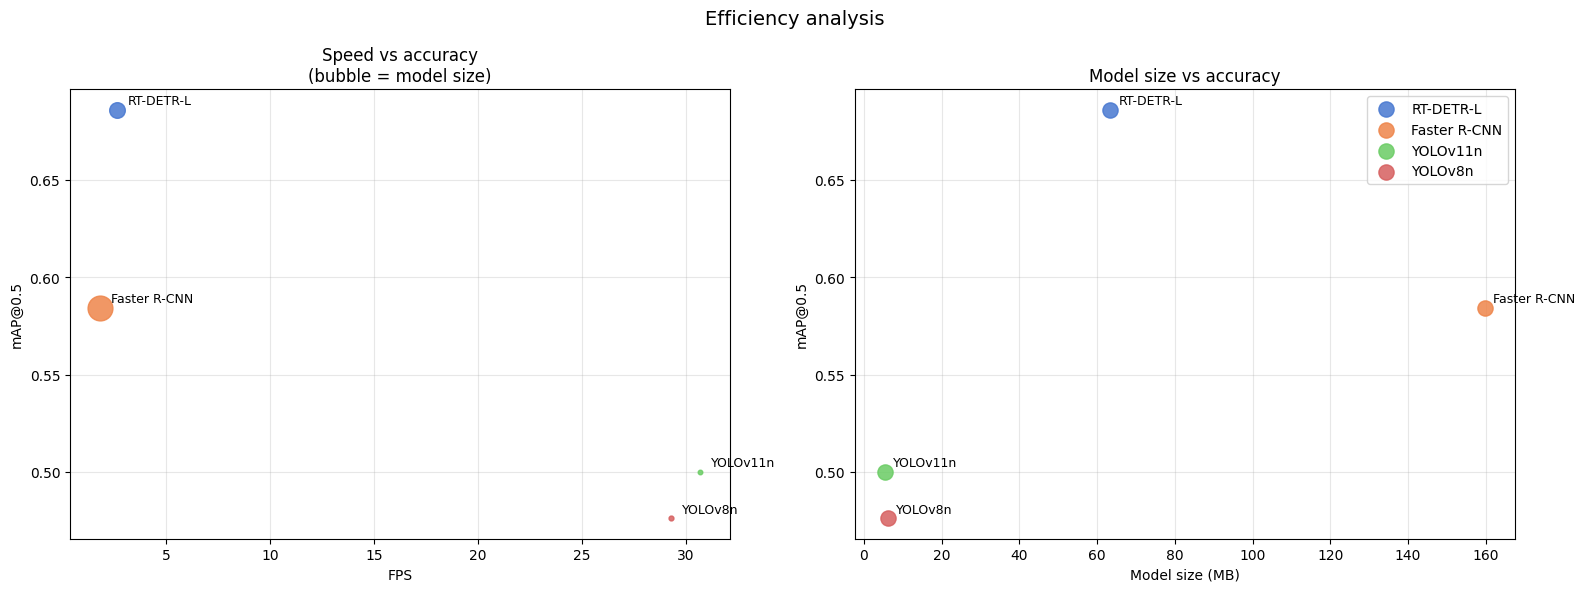

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for i, row in summary_df.iterrows():
    axes[0].scatter(row["fps"], row["map50"],
                    s=row["model_size_mb"] * 2, color=PALETTE[i], zorder=3, alpha=0.85)
    axes[0].annotate(row["model"], (row["fps"], row["map50"]),
                     textcoords="offset points", xytext=(8, 4), fontsize=9)

axes[0].set_xlabel("FPS")
axes[0].set_ylabel("mAP@0.5")
axes[0].set_title("Speed vs accuracy\n(bubble = model size)")
axes[0].grid(True, alpha=0.3)

for i, row in summary_df.iterrows():
    axes[1].scatter(row["model_size_mb"], row["map50"],
                    s=120, color=PALETTE[i], zorder=3, alpha=0.85, label=row["model"])
    axes[1].annotate(row["model"], (row["model_size_mb"], row["map50"]),
                     textcoords="offset points", xytext=(6, 4), fontsize=9)

axes[1].set_xlabel("Model size (MB)")
axes[1].set_ylabel("mAP@0.5")
axes[1].set_title("Model size vs accuracy")
axes[1].grid(True, alpha=0.3)
axes[1].legend()

plt.suptitle("Efficiency analysis", fontsize=14)
plt.tight_layout()
plt.savefig(f"{DATA_DIR}/analytics_efficiency.png", dpi=150, bbox_inches="tight")
plt.show()

## F1 score at varying confidence thresholds

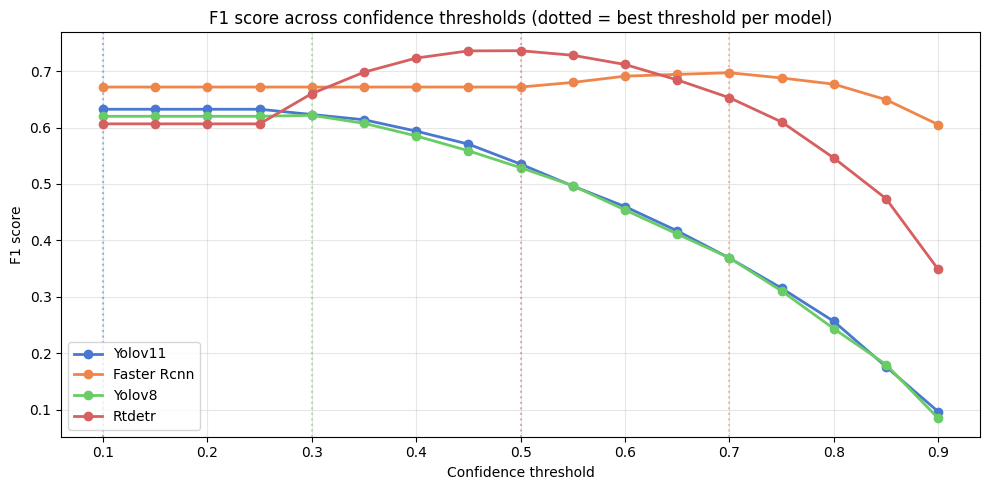

In [11]:
def f1_at_threshold(preds, gts, conf_thresh, iou_thresh=0.5):
    filtered = preds[preds["conf"] >= conf_thresh]
    if filtered.empty or gts.empty:
        return 0.0
    tp = fp = 0
    matched = set()
    for _, pred in filtered.iterrows():
        img_gts = gts[gts["filepath"] == pred["filepath"]]
        best_iou, best_idx = 0, -1
        for j, gt in img_gts.iterrows():
            if j in matched:
                continue
            iou = compute_iou(
                [pred["x1"], pred["y1"], pred["x2"], pred["y2"]],
                [gt["x1"], gt["y1"], gt["x2"], gt["y2"]]
            )
            if iou > best_iou:
                best_iou, best_idx = iou, j
        if best_iou >= iou_thresh and best_idx != -1:
            tp += 1
            matched.add(best_idx)
        else:
            fp += 1
    fn = len(gts) - tp
    precision = tp / (tp + fp + 1e-6)
    recall = tp / (tp + fn + 1e-6)
    return 2 * precision * recall / (precision + recall + 1e-6)

if preds_map:
    thresholds = np.arange(0.1, 0.95, 0.05)
    fig, ax = plt.subplots(figsize=(10, 5))

    for i, (key, preds) in enumerate(preds_map.items()):
        f1_scores = [f1_at_threshold(preds, gt_df, t) for t in thresholds]
        ax.plot(thresholds, f1_scores, "o-", linewidth=2, color=PALETTE[i],
                label=key.replace("_", " ").title())
        best_t = thresholds[np.argmax(f1_scores)]
        ax.axvline(best_t, color=PALETTE[i], linestyle=":", alpha=0.5)

    ax.set_xlabel("Confidence threshold")
    ax.set_ylabel("F1 score")
    ax.set_title("F1 score across confidence thresholds (dotted = best threshold per model)")
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(f"{DATA_DIR}/analytics_f1_threshold.png", dpi=150, bbox_inches="tight")
    plt.show()